## Домашнее задание 5

Используйте датасет после обработки пропусков (из ДЗ 4).

- Найдите выбросы для `ApplicantIncome` и `LoanAmount` двумя способами:
  - IQR-правило
  - метод стандартного отклонения (std)  
  — **4 балла**

- Сравните пересечение и расхождения списков наблюдений; кратко объясните причины различий — **4 балла**

- Визуально подтвердите наличие выбросов (boxplot / гистограммы) — **3 балла**

- Примите решение:
  - удалить выбросы,
  - заменить,
  - оставить  
  Обоснуйте выбор — **3 балла**

- Предложите варианты кодирования категориальных переменных, обоснуйте выбор — **3 балла**

- Примените выбранные правила перекодирования — **2 балла**

- Проверьте результат (типы данных, размерность, отсутствие ошибок) — **1 балл**

---

Для сдачи домашней работы запушьте файлы в ветку **hw_5** в вашем репозитории, создайте pull-request и отправьте на ревью @lyutovad 


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('loan_prediction_dataset.csv')

Найдите выбросы для ApplicantIncome и LoanAmount двумя способами:

IQR-правило
метод стандартного отклонения (std)
— 4 балла

In [2]:
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)].index.tolist()

def find_outliers_std(df, column):
    mean = df[column].mean()
    std = df[column].std()
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)].index.tolist()

#применяем методы
iqr_outliers_income = find_outliers_iqr(df, 'ApplicantIncome')
std_outliers_income = find_outliers_std(df, 'ApplicantIncome')

iqr_outliers_loan = find_outliers_iqr(df, 'LoanAmount')
std_outliers_loan = find_outliers_std(df, 'LoanAmount')

print(f"IQR выбросы (Income): {len(iqr_outliers_income)}")
print(f"STD выбросы (Income): {len(std_outliers_income)}")
print(f"IQR выбросы (Loan): {len(iqr_outliers_loan)}")
print(f"STD выбросы (Loan): {len(std_outliers_loan)}")

IQR выбросы (Income): 50
STD выбросы (Income): 8
IQR выбросы (Loan): 39
STD выбросы (Loan): 14


Сравните пересечение и расхождения списков наблюдений; кратко объясните причины различий — 4 балла

Метод IQR обычно находит больше выбросов, так как он ориентируется на плотность основной массы данных (межквартильный размах). Метод STD (3-х сигм) более консервативен и срабатывает только на экстремальных отклонениях.
Причины различий:
Данные о доходах часто имеют «тяжелый хвост» (распределение смещено вправо).
Метод STD предполагает нормальное распределение, а IQR — нет. Если распределение не нормальное, STD может «пропускать» аномалии, которые IQR легко помечает как выбросы.

Визуально подтвердите наличие выбросов (boxplot / гистограммы) — 3 балла

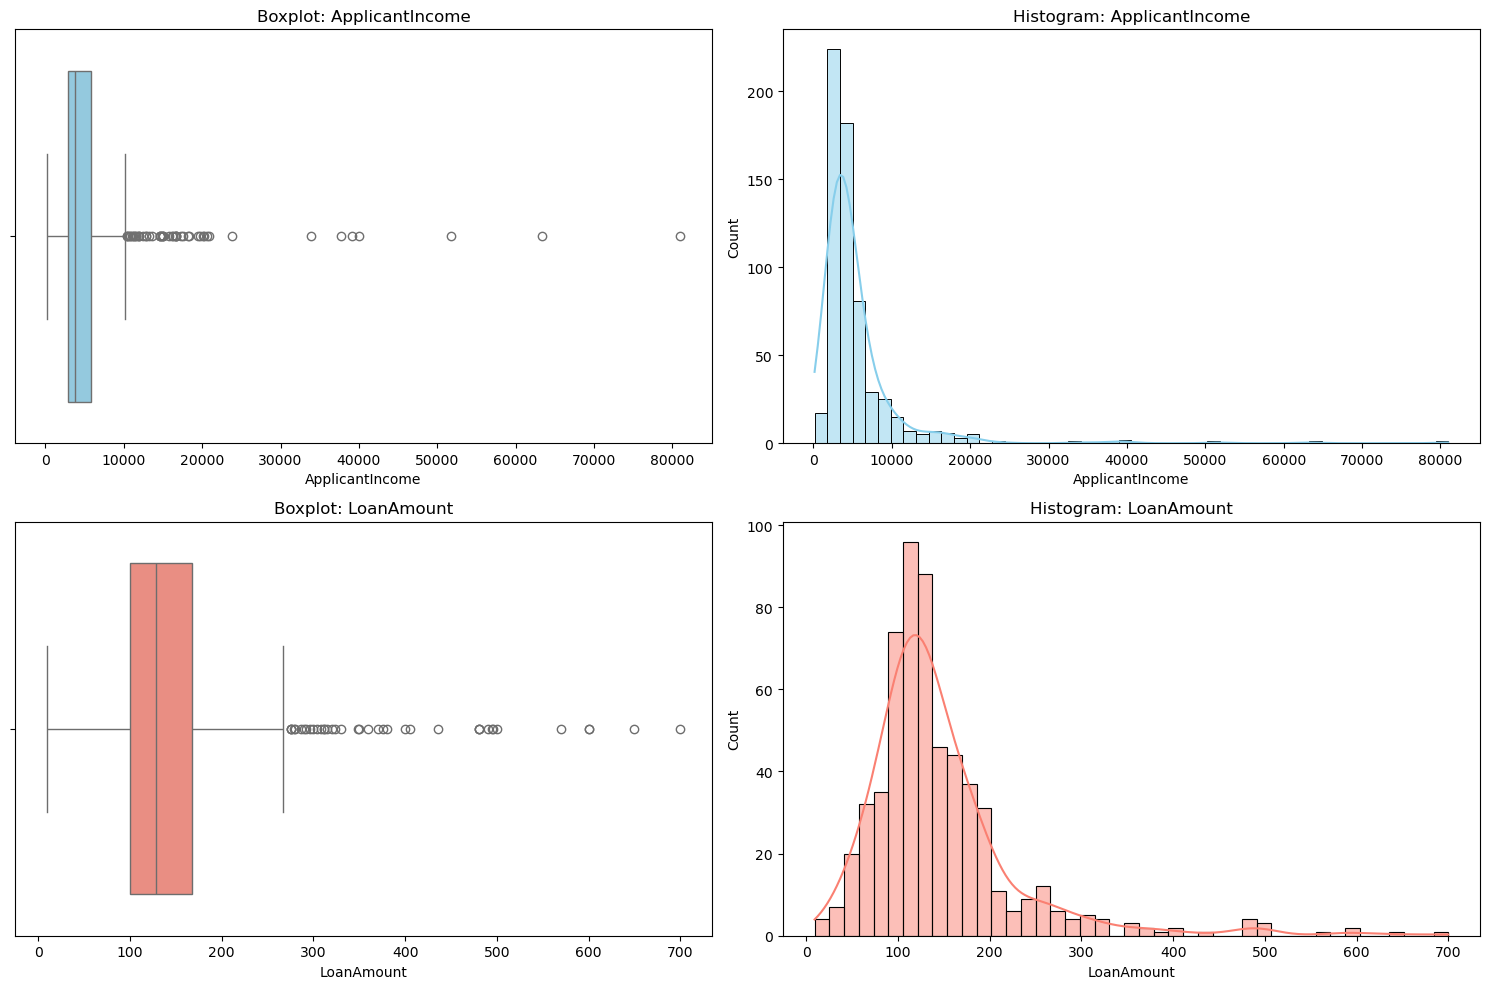

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

#applicantIncome
sns.boxplot(x=df['ApplicantIncome'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Boxplot: ApplicantIncome')

sns.histplot(df['ApplicantIncome'], kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Histogram: ApplicantIncome')

#LoanAmount
sns.boxplot(x=df['LoanAmount'], ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Boxplot: LoanAmount')

sns.histplot(df['LoanAmount'], kde=True, ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Histogram: LoanAmount')

plt.tight_layout()
plt.show()

Примите решение:

удалить выбросы,
заменить,
оставить
Обоснуйте выбор — 3 балла

Оставить выбросы без изменений.
В финансах высокие доходы и крупные кредиты - это не ошибки, а реальные клиенты.
На гистограммах видно, что данные «затухают» постепенно, а не стоят отдельными точками.
Если мы удалим эти строки, модель «не узнает» о существовании богатых заемщиков, что снизит точность прогнозов.

Предложите варианты кодирования категориальных переменных, обоснуйте выбор — 3 балла

Для подготовки данных я предлагаю использовать три разных подхода в зависимости от типа признака:

**Бинарное кодирование**
Для Gender, Married, Education, Self_Employed, Loan_Status
Обоснование: Эти признаки имеют всего два значения (например, Male/Female или Yes/No)

**Порядковое кодирование**
Для Dependents (количество иждивенцев: 0, 1, 2, 3+)
Здесь существует естественный порядок (0 < 1 < 2 < 3). Если мы используем простое кодирование, мы сохраним эту математическую зависимость, что поможет модели понять: чем больше значение, тем больше у человека обязательств

**One-Hot Encoding (OHE / Дамми-переменные)**
Для Property_Area (Rural, Semiurban, Urban).
В типах местности нет строгого порядка «от меньшего к большему» в контексте весов модели. Если назначить им числа 0, 1 и 2, модель может ошибочно решить, что Urban (2) «в два раза больше» Rural (0). Создание трех отдельных столбцов (0 или 1 для каждого типа) исключает эту проблему

Примените выбранные правила перекодирования — 2 балла

In [4]:
#создаем копию датасета, чтобы сохранить исходные данные для сравнения
df_encoded = df.copy()

#бинарное кодирование (Label Mapping)
# Мы явно назначаем 1 и 0, чтобы контролировать интерпретацию (например, Yes = 1)
binary_map = {
    'Gender': {'Male': 1, 'Female': 0},
    'Married': {'Yes': 1, 'No': 0},
    'Education': {'Graduate': 1, 'Not Graduate': 0},
    'Self_Employed': {'Yes': 1, 'No': 0},
    'Loan_Status': {'Y': 1, 'N': 0}
}

for column, values in binary_map.items():
    df_encoded[column] = df_encoded[column].map(values)

#обработка признака Dependents (Порядковый)
#чтобы избежать ошибки ValueError при конвертации в int, 
#сначала заполняем пропуски модой (самым частым значением)
df_encoded['Dependents'] = df_encoded['Dependents'].fillna(df_encoded['Dependents'].mode()[0])

#oпереводим строковое '3+' в число 3 и меняем тип данных на целочисленный
df_encoded['Dependents'] = df_encoded['Dependents'].replace('3+', 3).astype(int)

#ne-Hot Encoding для Property_Area
#создаем отдельные столбцы для Urban, Semiurban и Rural
#drop_first=True можно использовать для уменьшения мультиколлинеарности, 
#но для учебных целей оставим все столбцы для наглядности
df_encoded = pd.get_dummies(df_encoded, columns=['Property_Area'], prefix='Area')

#удаление неинформативных признаков
#столбец Loan_ID — это просто уникальный номер заявки, он не помогает предсказывать кредит
if 'Loan_ID' in df_encoded.columns:
    df_encoded.drop('Loan_ID', axis=1, inplace=True)

print("Кодирование успешно завершено.")

Кодирование успешно завершено.


Проверьте результат (типы данных, размерность, отсутствие ошибок) — 1 балл

In [5]:
#проверка типов данных
print("типы данных после кодирования")
print(df_encoded.dtypes)

#проверка размерности
print(f"\nРазмерность до: {df.shape}")
print(f"Размерность после: {df_encoded.shape}")

#проверка на отсутствие NaN
print(f"\nКоличество пропусков: {df_encoded.isnull().sum().sum()}")

#вывод первых 5 строк
df_encoded.head()

--- Типы данных после кодирования ---
Gender               float64
Married              float64
Dependents             int64
Education              int64
Self_Employed        float64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Loan_Status            int64
Area_Rural              bool
Area_Semiurban          bool
Area_Urban              bool
dtype: object

Размерность до: (614, 13)
Размерность после: (614, 14)

Количество пропусков: 134


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Area_Rural,Area_Semiurban,Area_Urban
0,1.0,0.0,0,1,0.0,5849,0.0,NaN,360.0,1.0,1,False,False,True
1,1.0,1.0,1,1,0.0,4583,1508.0,128.0,360.0,1.0,0,True,False,False
2,1.0,1.0,0,1,1.0,3000,0.0,66.0,360.0,1.0,1,False,False,True
3,1.0,1.0,0,0,0.0,2583,2358.0,120.0,360.0,1.0,1,False,False,True
4,1.0,0.0,0,1,0.0,6000,0.0,141.0,360.0,1.0,1,False,False,True
